## Weights selection and construction of final portfolio


In [ ]:
# ====== HRP ======
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform

#Import names of stocks to long and short

file_id = '1l6Ms10hLmhAveuuUaWM2JRn1GVVr1wbN'
file_url = f'https://drive.google.com/uc?id={file_id}'

output = 'Tickers.xlsx'
gdown.download(file_url, output, quiet=False)


us_long_names = pd.read_excel(output,sheet_name=0, header=0, usecols="A")
us_short_names = pd.read_excel(output,sheet_name=1, header=0, usecols="A")

eu_long_names = pd.read_excel(output,sheet_name=2, header=0, usecols="A")
eu_short_names = pd.read_excel(output,sheet_name=3, header=0, usecols="A")

# Merge into one dataframe
#long_data = pd.concat([eu_long_names, us_long_names], axis=0, ignore_index=True)
#short_data = pd.concat([eu_short_names, us_short_names], axis=0, ignore_index=True)

def norm(s):
    return (s.astype(str)
              .str.strip()
              .replace({"": pd.NA})
              .dropna()
              .unique()
              .tolist())

long_names_eu = norm(eu_long_names['TICKER'])
long_names_us = norm(us_long_names['TICKER'])
short_names_eu = norm(eu_short_names['TICKER'])
short_names_us = norm(us_short_names['TICKER'])

Downloading...
From: https://drive.google.com/uc?id=1l6Ms10hLmhAveuuUaWM2JRn1GVVr1wbN
To: /content/Tickers.xlsx
100%|██████████| 23.2k/23.2k [00:00<00:00, 38.7MB/s]


In [ ]:
print(short_names_us)

['EXPD.N', 'SYY.N', 'HST.OQ', 'FCX.N', 'PLTR.OQ', 'AXP.N', 'JNJ.N', 'SPG.N', 'L.N', 'OXY.N', 'OMC.N', 'WYNN.OQ', 'MGM.N', 'MAR.OQ', 'WFC.N', 'DTE.N', 'MCHP.OQ', 'MRNA.OQ', 'BRKb.N', 'COP.N']


In [ ]:
#Import data of daily prices of the selected stocks to be optimized using HRP approach

file_id = '1oy0zrqGXpOW7rM1XQ5WU_9HlX6Spkr8f'
file_url = f'https://drive.google.com/uc?id={file_id}'

# Download the Excel file
output = 'EU_Returns.xlsx'
gdown.download(file_url, output, quiet=False)

# Load the sheets
eu_returns = pd.read_excel(output, sheet_name=0, index_col=0)

file_id = '1jDIZKHsSfAKk61TJauSfhFSnTgx8nZgi'
file_url = f'https://drive.google.com/uc?id={file_id}'

# Download the Excel file
output = 'US_Returns.xlsx'
gdown.download(file_url, output, quiet=False)

us_returns = pd.read_excel(output, sheet_name=0, index_col=0)

# Merge into one dataframe
data = pd.concat([us_returns, eu_returns], axis=1)

# mv_returns is a DataFrame/Series
data = data.apply(pd.to_numeric, errors='coerce')
# forward then back fill to handle NaNs
data = data.ffill().bfill()

Downloading...
From: https://drive.google.com/uc?id=1oy0zrqGXpOW7rM1XQ5WU_9HlX6Spkr8f
To: /content/EU_Returns.xlsx
100%|██████████| 610k/610k [00:00<00:00, 96.2MB/s]
Downloading...
From: https://drive.google.com/uc?id=1jDIZKHsSfAKk61TJauSfhFSnTgx8nZgi
To: /content/US_Returns.xlsx
100%|██████████| 587k/587k [00:00<00:00, 104MB/s]


In [ ]:
# Select the relevant data for long and short legs
selected_stocks_long_eu = [s for s in long_names_eu if s in data.columns]
selected_stocks_short_eu = [s for s in short_names_eu if s in data.columns]
selected_stocks_long_us = [s for s in long_names_us if s in data.columns]
selected_stocks_short_us = [s for s in short_names_us if s in data.columns]

filtered_data_long_eu = data[selected_stocks_long_eu]
filtered_data_short_eu = data[selected_stocks_short_eu]
filtered_data_long_us = data[selected_stocks_long_us]
filtered_data_short_us = data[selected_stocks_short_us]


In [ ]:
print(filtered_data_short_us)

            EXPD.N  SYY.N     HST.OQ      FCX.N  PLTR.OQ   AXP.N   JNJ.N  \
Date                                                                       
1/31/2015   120.34  39.17  22.012556  16.699037    10.13   80.69  100.14   
2/28/2015   120.34  38.99  20.195005  21.487220    10.13   81.59  102.51   
3/31/2015   120.34  37.73  19.406438  18.824911    10.13   78.12  100.60   
4/30/2015   120.34  37.03  19.367972  23.116395    10.13   77.45   99.20   
5/31/2015   120.34  37.16  19.156405  19.520290    10.13   79.72  100.14   
...            ...    ...        ...        ...      ...     ...     ...   
6/30/2025   114.25  75.74  15.360000  43.350000   136.32  318.98  152.75   
7/31/2025   116.24  79.60  15.720000  40.240000   158.35  299.31  164.74   
8/31/2025   120.54  80.47  17.210000  44.400000   156.71  331.28  177.17   
9/30/2025   122.59  82.34  17.210000  39.220000   182.42  332.16  185.42   
10/31/2025  121.90  74.28  17.210000  41.700000   200.47  360.73  188.87   

           

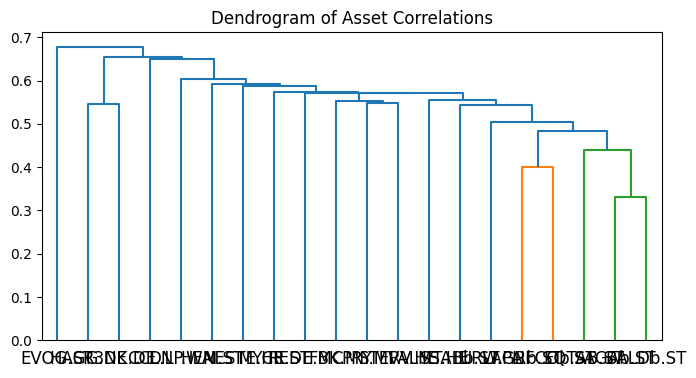

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

# ---- 2. Compute returns and correlation/covariance ----
mv_returns = filtered_data_long_eu.pct_change(fill_method=None).iloc[2:]
# Remove columns with no variation which break corr
mv_returns = mv_returns.loc[:, mv_returns.std(skipna=True) > 0]

# Save the names
tickers = mv_returns.columns.tolist()

# Log return
logRetAll = np.log1p(mv_returns)

# Drop rows that are all NaN and fill rare gaps with 0
logRetAll = logRetAll.replace([np.inf, -np.inf], np.nan)
logRetAll = logRetAll.dropna(how="all").fillna(0)

# --- corr/cov ---
corrTrain = np.corrcoef(logRetAll, rowvar=False)

# Bound it to [-1, 1] and force diagonal to 1
corrTrain = np.clip(corrTrain, -1.0, 1.0)
np.fill_diagonal(corrTrain, 1.0)

covTrain = np.cov(logRetAll, rowvar=False) * 252  # Annualized covariance

# --- Distance (finite & condensed) ---
D = np.sqrt(0.5 * (1 - corrTrain)) # Distance matrix
np.fill_diagonal(D, 0.0)

# if any stray NaNs remain (e.g., degenerate columns), replace with 0 distance on diag and mean off-diag
if not np.isfinite(D).all():
    # simple, safe fallback: replace non-finite with column means
    col_means = np.nanmean(np.where(np.isfinite(D), D, np.nan), axis=0)
    D = np.where(np.isfinite(D), D, col_means[None, :])
    D = np.where(np.isfinite(D), D, 0.0)
    np.fill_diagonal(D, 0.0)

# Condensed vector for scipy.linkage
D_condensed = squareform(D, checks=False)

# --- clustering/dendrogram ---
Z = linkage(D_condensed, method='single')
res_order = leaves_list(Z).astype(int)             # order of assets along dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z, labels = tickers)
plt.title("Dendrogram of Asset Correlations")
plt.show()




In [ ]:
from cuml import AgglomerativeClustering as AC
# Create single linkage cluster using the Euclidean metric
def cluster(D):
    model=AC(affinity='l2', connectivity='pairwise', linkage='single')
    model.fit(D);
    return model.children_


In [ ]:
def seriation(Z):
    N = Z.shape[1]
    stack = [2*N-2]
    res_order = []
    while(len(stack) != 0):
        cur_idx = stack.pop()
        if cur_idx < N:
            res_order.append(cur_idx)
        else:
            stack.append(int(Z[1, cur_idx-N]))
            stack.append(int(Z[0, cur_idx-N]))
    return res_order

In [ ]:
# --- HRP recursive bisection  ---
#Performs recursive bisection weighting for a new portfolio

    #V is the sorted correlation matrix
    #l is the left index of the recursion
    #r is the right index of the recursion
    #W is the list of weights

def recursiveBisection(V, l, r, W):

    if r - l == 1:
        return W
    mid = l + (r - l) // 2
    V1 = V[l:mid, l:mid]
    V2 = V[mid:r, mid:r]

    inv1 = 1.0 / np.diag(V1)
    inv2 = 1.0 / np.diag(V2)
    w1 = inv1 / inv1.sum()
    w2 = inv2 / inv2.sum()

    var1 = float(w1.T @ V1 @ w1)
    var2 = float(w2.T @ V2 @ w2)

    a2 = var1 / (var1 + var2)   # weight going to the right block
    a1 = 1.0 - a2               # weight to the left block

    W[l:mid] *= a1
    W[mid:r] *= a2

    recursiveBisection(V, l, mid, W)
    recursiveBisection(V, mid, r, W)
    return W


In [ ]:
# --- Compute final weights ---
N = len(res_order)
V_sorted = covTrain[np.ix_(res_order, res_order)]
W_sorted = recursiveBisection(V_sorted, 0, N, np.ones(N, dtype=float))
W = np.empty_like(W_sorted)
W[res_order] = W_sorted       # map back to original order
W = np.maximum(W, 0)          # guard tiny negative due to roundoff
W /= W.sum()

In [ ]:
# Define the Helper

def cap_proportional(w, cap=0.10, target_sum=0.5):
    """
    Cap each weight at `cap` and redistribute excess proportionally.
    Normalize to sum = target_sum (e.g. 0.5 for 50% exposure).
    """
    w = np.asarray(w, float).clip(min=0)
    if w.sum() == 0:
        return w
    w /= w.sum()  # normalize to 1 before capping

    for _ in range(100):  # iterative redistribution
        over = w > cap
        if not over.any():
            break
        excess = (w[over] - cap).sum()
        w[over] = cap
        under = ~over
        if under.sum() == 0 or excess <= 0:
            break
        share = w[under]
        w[under] += excess * (share / share.sum())
    w = np.clip(w, 0, cap)
    w /= w.sum() if w.sum() else 1
    return w * target_sum  # enforce total sum = target_sum

In [ ]:
# Run the cap
weights_capped = cap_proportional(W, cap=0.10, target_sum=0.5)

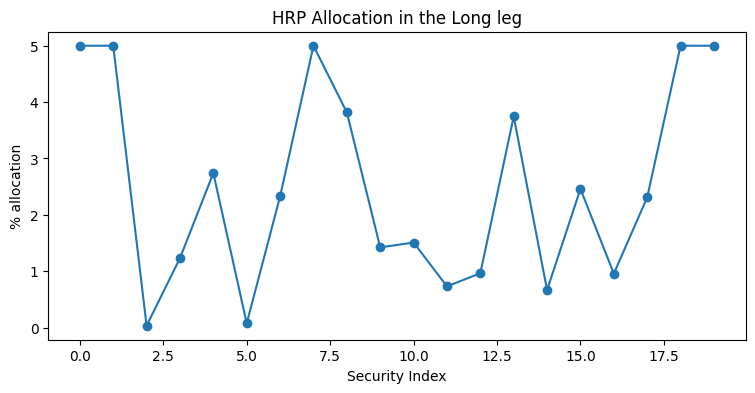

In [ ]:
# --- Plot final weights ---
plt.figure(figsize=(9,4))
plt.plot(weights_capped * 100.0, marker='o')
plt.xlabel("Security Index")
plt.ylabel("% allocation")
plt.title("HRP Allocation in the Long leg")
plt.show()

In [ ]:
# --- Export weights with stock names ---
weights_long_eu = pd.DataFrame({
    'Stock': tickers,
    'Weight': weights_capped
})

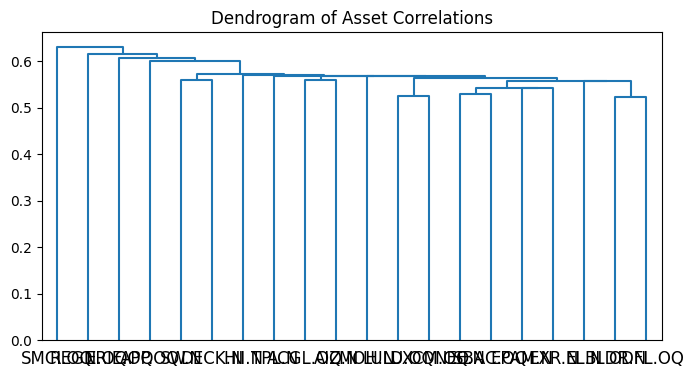

In [ ]:
# ---- 2. Compute returns and correlation/covariance ----
mv_returns = filtered_data_long_us.pct_change(fill_method=None).iloc[2:]
# Remove columns with no variation which break corr
mv_returns = mv_returns.loc[:, mv_returns.std(skipna=True) > 0]

# Save the names
tickers = mv_returns.columns.tolist()

# Log return
logRetAll = np.log1p(mv_returns)

# Drop rows that are all NaN and fill rare gaps with 0
logRetAll = logRetAll.replace([np.inf, -np.inf], np.nan)
logRetAll = logRetAll.dropna(how="all").fillna(0)

# --- corr/cov ---
corrTrain = np.corrcoef(logRetAll, rowvar=False)

# Bound it to [-1, 1] and force diagonal to 1
corrTrain = np.clip(corrTrain, -1.0, 1.0)
np.fill_diagonal(corrTrain, 1.0)

covTrain = np.cov(logRetAll, rowvar=False) * 252  # Annualized covariance

# --- Distance (finite & condensed) ---
D = np.sqrt(0.5 * (1 - corrTrain)) # Distance matrix
np.fill_diagonal(D, 0.0)

# if any stray NaNs remain (e.g., degenerate columns), replace with 0 distance on diag and mean off-diag
if not np.isfinite(D).all():
    # simple, safe fallback: replace non-finite with column means
    col_means = np.nanmean(np.where(np.isfinite(D), D, np.nan), axis=0)
    D = np.where(np.isfinite(D), D, col_means[None, :])
    D = np.where(np.isfinite(D), D, 0.0)
    np.fill_diagonal(D, 0.0)

# Condensed vector for scipy.linkage
D_condensed = squareform(D, checks=False)

# --- clustering/dendrogram ---
Z = linkage(D_condensed, method='single')
res_order = leaves_list(Z).astype(int)             # order of assets along dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z, labels = tickers)
plt.title("Dendrogram of Asset Correlations")
plt.show()

In [ ]:
# Create single linkage cluster using the Euclidean metric
def cluster(D):
    model=AC(affinity='l2', connectivity='pairwise', linkage='single')
    model.fit(D);
    return model.children_

In [ ]:
def seriation(Z):
    N = Z.shape[1]
    stack = [2*N-2]
    res_order = []
    while(len(stack) != 0):
        cur_idx = stack.pop()
        if cur_idx < N:
            res_order.append(cur_idx)
        else:
            stack.append(int(Z[1, cur_idx-N]))
            stack.append(int(Z[0, cur_idx-N]))
    return res_order

In [ ]:
# --- HRP recursive bisection  ---
#Performs recursive bisection weighting for a new portfolio

    #V is the sorted correlation matrix
    #l is the left index of the recursion
    #r is the right index of the recursion
    #W is the list of weights

def recursiveBisection(V, l, r, W):

    if r - l == 1:
        return W
    mid = l + (r - l) // 2
    V1 = V[l:mid, l:mid]
    V2 = V[mid:r, mid:r]

    inv1 = 1.0 / np.diag(V1)
    inv2 = 1.0 / np.diag(V2)
    w1 = inv1 / inv1.sum()
    w2 = inv2 / inv2.sum()

    var1 = float(w1.T @ V1 @ w1)
    var2 = float(w2.T @ V2 @ w2)

    a2 = var1 / (var1 + var2)   # weight going to the right block
    a1 = 1.0 - a2               # weight to the left block

    W[l:mid] *= a1
    W[mid:r] *= a2

    recursiveBisection(V, l, mid, W)
    recursiveBisection(V, mid, r, W)
    return W

In [ ]:
# --- Compute final weights ---
N = len(res_order)
V_sorted = covTrain[np.ix_(res_order, res_order)]
W_sorted = recursiveBisection(V_sorted, 0, N, np.ones(N, dtype=float))
W = np.empty_like(W_sorted)
W[res_order] = W_sorted       # map back to original order
W = np.maximum(W, 0)          # guard tiny negative due to roundoff
W /= W.sum()

In [ ]:
# Run the cap
weights_capped = cap_proportional(W, cap=0.10, target_sum=0.5)

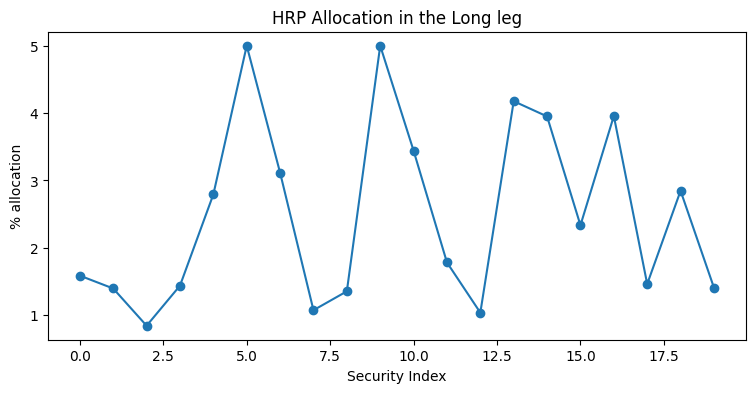

In [ ]:
# --- Plot final weights ---
plt.figure(figsize=(9,4))
plt.plot(weights_capped * 100.0, marker='o')
plt.xlabel("Security Index")
plt.ylabel("% allocation")
plt.title("HRP Allocation in the Long leg")
plt.show()

In [ ]:
# --- Export weights with stock names ---
weights_long_us = pd.DataFrame({
    'Stock': tickers,
    'Weight': weights_capped
})

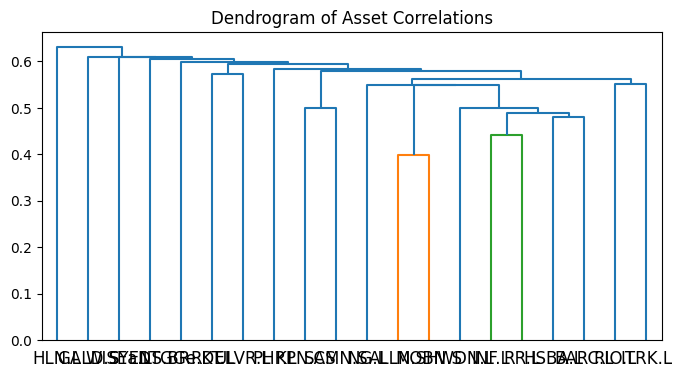

In [ ]:
# Same for the short leg
# ---- 2. Compute returns and correlation/covariance ----
mv_returns = filtered_data_short_eu.pct_change(fill_method=None).iloc[1:]

# Remove columns with no variation which break corr
mv_returns = mv_returns.loc[:, mv_returns.std(skipna=True) > 0]

# Save the names
tickers = mv_returns.columns.tolist()

# Log return
logRetAll = np.log1p(mv_returns)

# Drop rows that are all NaN and fill rare gaps with 0
logRetAll = logRetAll.replace([np.inf, -np.inf], np.nan)
logRetAll = logRetAll.dropna(how="all").fillna(0)

# --- corr/cov ---
corrTrain = np.corrcoef(logRetAll, rowvar=False)

# Bound it to [-1, 1] and force diagonal to 1
corrTrain = np.clip(corrTrain, -1.0, 1.0)
np.fill_diagonal(corrTrain, 1.0)

covTrain = np.cov(logRetAll, rowvar=False) * 252  # Annualized covariance

# --- Distance (finite & condensed) ---
D = np.sqrt(0.5 * (1 - corrTrain)) # Distance matrix
np.fill_diagonal(D, 0.0)

# if any stray NaNs remain (e.g., degenerate columns), replace with 0 distance on diag and mean off-diag
if not np.isfinite(D).all():
    # simple, safe fallback: replace non-finite with column means
    col_means = np.nanmean(np.where(np.isfinite(D), D, np.nan), axis=0)
    D = np.where(np.isfinite(D), D, col_means[None, :])
    D = np.where(np.isfinite(D), D, 0.0)
    np.fill_diagonal(D, 0.0)

# Condensed vector for scipy.linkage
D_condensed = squareform(D, checks=False)

# --- clustering/dendrogram ---
Z = linkage(D_condensed, method='single')
res_order = leaves_list(Z).astype(int)             # order of assets along dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z , labels = tickers)
plt.title("Dendrogram of Asset Correlations")
plt.show()



In [ ]:
# Create single linkage cluster using the Euclidean metric
def cluster(D):
    model=AC(affinity='l2', connectivity='pairwise', linkage='single')
    model.fit(D);
    return model.children_


In [ ]:
def seriation(Z):
    N = Z.shape[1]
    stack = [2*N-2]
    res_order = []
    while(len(stack) != 0):
        cur_idx = stack.pop()
        if cur_idx < N:
            res_order.append(cur_idx)
        else:
            stack.append(int(Z[1, cur_idx-N]))
            stack.append(int(Z[0, cur_idx-N]))
    return res_order

In [ ]:
# --- HRP recursive bisection  ---
#Performs recursive bisection weighting for a new portfolio

    #V is the sorted correlation matrix
    #l is the left index of the recursion
    #r is the right index of the recursion
    #W is the list of weights

def recursiveBisection(V, l, r, W):

    if r - l == 1:
        return W
    mid = l + (r - l) // 2
    V1 = V[l:mid, l:mid]
    V2 = V[mid:r, mid:r]

    inv1 = 1.0 / np.diag(V1)
    inv2 = 1.0 / np.diag(V2)
    w1 = inv1 / inv1.sum()
    w2 = inv2 / inv2.sum()

    var1 = float(w1.T @ V1 @ w1)
    var2 = float(w2.T @ V2 @ w2)

    a2 = var1 / (var1 + var2)   # weight going to the right block
    a1 = 1.0 - a2               # weight to the left block

    W[l:mid] *= a1
    W[mid:r] *= a2

    recursiveBisection(V, l, mid, W)
    recursiveBisection(V, mid, r, W)
    return W

In [ ]:
# --- Compute final weights ---
N = len(res_order)
V_sorted = covTrain[np.ix_(res_order, res_order)]
W_sorted = recursiveBisection(V_sorted, 0, N, np.ones(N, dtype=float))
W = np.empty_like(W_sorted)
W[res_order] = W_sorted       # map back to original order
W = np.maximum(W, 0)          # guard tiny negative due to roundoff
W /= W.sum()


In [ ]:
# Run the cap
weights_capped = cap_proportional(W, cap=0.10, target_sum=0.5)

In [ ]:
# Invert the portfolio (flip longs/shorts)
weights_capped = -1*weights_capped

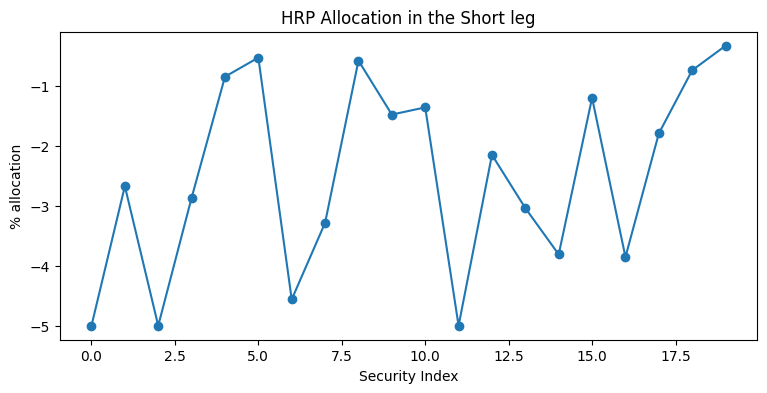

In [ ]:
# --- Plot final weights ---
plt.figure(figsize=(9,4))
plt.plot(weights_capped * 100.0, marker='o')
plt.xlabel("Security Index")
plt.ylabel("% allocation")
plt.title("HRP Allocation in the Short leg")
plt.show()

In [ ]:
# --- Export weights with stock names ---
weights_short_eu = pd.DataFrame({
    'Stock': tickers,
    'Weight': weights_capped
})

In [ ]:
# Same for the short leg
# ---- 2. Compute returns and correlation/covariance ----
mv_returns = filtered_data_short_us.pct_change(fill_method=None).iloc[1:]

# Remove columns with no variation which break corr
mv_returns = mv_returns.loc[:, mv_returns.std(skipna=True) > 0]

# Save the names
tickers = mv_returns.columns.tolist()

# Log return
logRetAll = np.log1p(mv_returns)

# Drop rows that are all NaN and fill rare gaps with 0
logRetAll = logRetAll.replace([np.inf, -np.inf], np.nan)
logRetAll = logRetAll.dropna(how="all").fillna(0)

# --- corr/cov ---
corrTrain = np.corrcoef(logRetAll, rowvar=False)

# Bound it to [-1, 1] and force diagonal to 1
corrTrain = np.clip(corrTrain, -1.0, 1.0)
np.fill_diagonal(corrTrain, 1.0)

covTrain = np.cov(logRetAll, rowvar=False) * 252  # Annualized covariance

# --- Distance (finite & condensed) ---
D = np.sqrt(0.5 * (1 - corrTrain)) # Distance matrix
np.fill_diagonal(D, 0.0)

# if any stray NaNs remain (e.g., degenerate columns), replace with 0 distance on diag and mean off-diag
if not np.isfinite(D).all():
    # simple, safe fallback: replace non-finite with column means
    col_means = np.nanmean(np.where(np.isfinite(D), D, np.nan), axis=0)
    D = np.where(np.isfinite(D), D, col_means[None, :])
    D = np.where(np.isfinite(D), D, 0.0)
    np.fill_diagonal(D, 0.0)

# Condensed vector for scipy.linkage
D_condensed = squareform(D, checks=False)

# --- clustering/dendrogram ---
Z = linkage(D_condensed, method='single')
res_order = leaves_list(Z).astype(int)             # order of assets along dendrogram
plt.figure(figsize=(8, 4))
dendrogram(Z , labels = tickers)
plt.title("Dendrogram of Asset Correlations")
plt.show()



NameError: name 'filtered_data_short_us' is not defined

In [ ]:
# Create single linkage cluster using the Euclidean metric
def cluster(D):
    model=AC(affinity='l2', connectivity='pairwise', linkage='single')
    model.fit(D);
    return model.children_


In [ ]:
def seriation(Z):
    N = Z.shape[1]
    stack = [2*N-2]
    res_order = []
    while(len(stack) != 0):
        cur_idx = stack.pop()
        if cur_idx < N:
            res_order.append(cur_idx)
        else:
            stack.append(int(Z[1, cur_idx-N]))
            stack.append(int(Z[0, cur_idx-N]))
    return res_order

In [ ]:
# --- HRP recursive bisection  ---
#Performs recursive bisection weighting for a new portfolio

    #V is the sorted correlation matrix
    #l is the left index of the recursion
    #r is the right index of the recursion
    #W is the list of weights

def recursiveBisection(V, l, r, W):

    if r - l == 1:
        return W
    mid = l + (r - l) // 2
    V1 = V[l:mid, l:mid]
    V2 = V[mid:r, mid:r]

    inv1 = 1.0 / np.diag(V1)
    inv2 = 1.0 / np.diag(V2)
    w1 = inv1 / inv1.sum()
    w2 = inv2 / inv2.sum()

    var1 = float(w1.T @ V1 @ w1)
    var2 = float(w2.T @ V2 @ w2)

    a2 = var1 / (var1 + var2)   # weight going to the right block
    a1 = 1.0 - a2               # weight to the left block

    W[l:mid] *= a1
    W[mid:r] *= a2

    recursiveBisection(V, l, mid, W)
    recursiveBisection(V, mid, r, W)
    return W

In [ ]:
# --- Compute final weights ---
N = len(res_order)
V_sorted = covTrain[np.ix_(res_order, res_order)]
W_sorted = recursiveBisection(V_sorted, 0, N, np.ones(N, dtype=float))
W = np.empty_like(W_sorted)
W[res_order] = W_sorted       # map back to original order
W = np.maximum(W, 0)          # guard tiny negative due to roundoff
W /= W.sum()


In [ ]:
# Run the cap
weights_capped = cap_proportional(W, cap=0.10, target_sum=0.5)

In [ ]:
# Invert the portfolio (flip longs/shorts)
weights_capped = -1*weights_capped


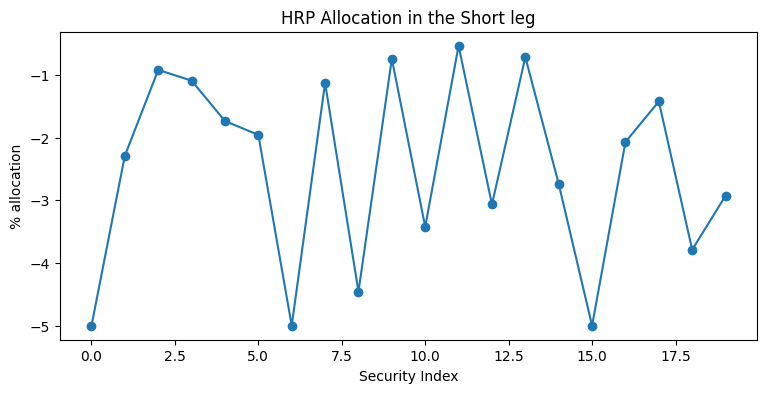

In [ ]:
# --- Plot final weights ---
plt.figure(figsize=(9,4))
plt.plot(weights_capped * 100.0, marker='o')
plt.xlabel("Security Index")
plt.ylabel("% allocation")
plt.title("HRP Allocation in the Short leg")
plt.show()

In [ ]:
# --- Export weights with stock names ---
weights_short_us = pd.DataFrame({
    'Stock': tickers,
    'Weight': weights_capped
})

In [ ]:
# Export the final portfolio to Excel
weights_df = pd.concat([weights_long_eu,weights_long_us,weights_short_eu,weights_short_us], axis=1)


In [ ]:
# Download all
from google.colab import files

weights_df.to_excel("hrp_weights.xlsx", index=False)
print("Saved HRP weights to hrp_weights.xlsx")
files.download('hrp_weights.xlsx')

Saved HRP weights to hrp_weights.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>